# Train transient DeepONet on Fluent cylinder trajectories

This notebook follows `train_deeponet.ipynb` for the transient ASCII exports in `runs_2d/cylinder`. One sample is one x-strip subdomain over the complete 100-snapshot trajectory (`case2d-0100` through `case2d-10000`). The compact dataset keeps targets as `(time, cell, field)` and only materializes sampled `(x, y, t)` trunk queries in the DataLoader.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import builtins
import sys
import logging
import subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from torch.utils.data import DataLoader
from datetime import datetime

MODULE_DIR = Path.cwd()
if not (MODULE_DIR / "fluent_deeponet.py").exists():
    MODULE_DIR = MODULE_DIR / "DeepONet"
ROOT_DIR = MODULE_DIR.parent

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from deeponet_fluent_dataset import (
    build_fluent_transient_deeponet_dataset,
    discover_fluent_transient_snapshots,
    load_rect_cylinder_geometry,
    TransientDeepONetCellDataset,
    deeponet_cell_collate_fn,
)

from fluent_deeponet import (
    FeatureNormalizer,
    DeepONet,
    train_transient_deeponet_one_epoch,
    evaluate_deeponet,
    predict_deeponet_points,
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:2")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

Device: cuda:2


In [2]:
comment = "Cylinder transient data; complete 100-step trajectory per x-strip sample, 5 realizations, 5k epochs"

In [3]:
def save_git_snapshot(run_dir):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    commands = {
        "git_commit.txt": ["git", "rev-parse", "HEAD"],
        "git_status.txt": ["git", "status"],
        "git_diff.patch": ["git", "diff"],
        "git_diff_cached.patch": ["git", "diff", "--cached"],
    }

    for filename, command in commands.items():
        with open(run_dir / filename, "w", encoding="utf-8") as f:
            subprocess.run(command, stdout=f, stderr=subprocess.STDOUT)

# Set to an existing run dir name (e.g. "transient_080526_1") or Path to resume
# logging/checkpointing there. Leave as None to create a new dated run directory.
RESUME_DIR = "transient_080526_1"

output_root = MODULE_DIR / "results"
output_root.mkdir(parents=True, exist_ok=True)

if RESUME_DIR is not None:
    output_dir = Path(RESUME_DIR)
    if not output_dir.is_absolute():
        output_dir = output_root / output_dir
    output_dir = output_dir.resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
else:
    today = datetime.now().strftime("%m%d%y")
    run_no = len([s for s in output_root.iterdir() if s.name.startswith(f"transient_{today}_")]) + 1
    output_str = f"transient_{today}_{run_no}"
    output_dir = output_root / output_str
    output_dir.mkdir(parents=True, exist_ok=True)

save_git_snapshot(output_dir / "code_snapshot")

logger = logging.getLogger("transient_deeponet")
logging.basicConfig(
    filename=output_dir / "training.log",
    level=logging.INFO,
    force=True,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

if not hasattr(builtins, "_orig_print"):
    builtins._orig_print = builtins.print
orig_print = builtins._orig_print
def print(*args, sep=" ", end="\n", file=None, flush=False):
    orig_print(*args, sep=sep, end=end, file=file, flush=flush)
    logger.info(sep.join(map(str, args)))

print("Training comment")
print(comment)
print("Output directory:", output_dir)
if RESUME_DIR is not None:
    print("Resuming into existing directory:", output_dir)

Training comment
Cylinder transient data; complete 100-step trajectory per x-strip sample, 5 realizations, 5k epochs
Output directory: /home/hantianl/Documents/PIDIF/DeepONet/results/transient_080526_1
Resuming into existing directory: /home/hantianl/Documents/PIDIF/DeepONet/results/transient_080526_1


## Case file paths

In [4]:
DATASET_NAME = "cylinder"
EXPECTED_STEPS = list(range(100, 10001, 100))

def case_paths(ch):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{DATASET_NAME}/{ch}.json",
        "data_dir": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/data",
        "mesh": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/{ch}_2d.msh.h5",
    }

def has_complete_trajectory(ch):
    paths = case_paths(ch)
    if not paths["design"].exists() or not paths["data_dir"].is_dir():
        return False
    snapshots = discover_fluent_transient_snapshots(paths["data_dir"])
    steps = [int(path.name.rsplit("-", 1)[1]) for path in snapshots]
    return steps == EXPECTED_STEPS

case_root = ROOT_DIR / "runs_2d" / DATASET_NAME
available_cases = sorted(
    [ch.name for ch in case_root.iterdir() if ch.is_dir() and has_complete_trajectory(ch.name)],
    key=lambda value: int(value.split("_")[-1]),
)
case_files = {ch: case_paths(ch) for ch in available_cases}

print(f"Available complete cases ({len(available_cases)}):")
print(available_cases)
assert available_cases, "No complete 100-snapshot cylinder trajectories were found"

Available complete cases (20):
['channel_000', 'channel_001', 'channel_002', 'channel_003', 'channel_004', 'channel_005', 'channel_006', 'channel_007', 'channel_008', 'channel_009', 'channel_010', 'channel_011', 'channel_012', 'channel_013', 'channel_014', 'channel_015', 'channel_016', 'channel_017', 'channel_018', 'channel_019']


# Training config

In [5]:
# 80/10/10 split by geometry/case so no trajectory appears in multiple splits.
SPLIT_SEED = 0
_split_rng = np.random.default_rng(SPLIT_SEED)
_shuffled_cases = list(available_cases)
_split_rng.shuffle(_shuffled_cases)

n_total = len(_shuffled_cases)
n_train = int(round(0.80 * n_total))
n_valid = int(round(0.10 * n_total))
TRAIN_CASES = sorted(_shuffled_cases[:n_train], key=lambda x: int(x.split("_")[-1]))
VALID_CASES = sorted(_shuffled_cases[n_train:n_train + n_valid], key=lambda x: int(x.split("_")[-1]))
TEST_CASES = sorted(_shuffled_cases[n_train + n_valid:], key=lambda x: int(x.split("_")[-1]))

print(f"Train cases ({len(TRAIN_CASES)}):", TRAIN_CASES)
print(f"Valid cases ({len(VALID_CASES)}):", VALID_CASES)
print(f"Test  cases ({len(TEST_CASES)}):", TEST_CASES)

# Each sample contains all 100 snapshots. A case therefore produces one
# temporal window per spatial x-strip, with no shorter or overlapping windows.
SNAPSHOTS_PER_SAMPLE = 100
WINDOW_STRIDE = 100

N_SUBDOMAINS = 10
INTERFACE_PLACEMENT = "random"
MIN_SUBDOMAIN_WIDTH = 0.01
CYLINDER_SUBDOMAIN_WIDTH = None
N_INTERFACE_POINTS = 128
N_BOUNDARY_POINTS = 128
N_INITIAL_POINTS = 2048
OUTPUT_FIELDS = ["pressure", "u", "v"]

# Query points are sampled from the 100 x n_cells Cartesian product.
N_QUERY_TRAIN = 8192
N_QUERY_VALID = 16384
BATCH_SIZE = 50

# Enforce prescribed physical-boundary values over all 100 times and the
# sampled initial field at t=0. Unknown boundary fields remain masked out.
LAMBDA_BC = 1.0
LAMBDA_IC = 1.0

Train cases (16): ['channel_000', 'channel_002', 'channel_003', 'channel_004', 'channel_005', 'channel_006', 'channel_007', 'channel_008', 'channel_010', 'channel_011', 'channel_012', 'channel_013', 'channel_016', 'channel_017', 'channel_018', 'channel_019']
Valid cases (2): ['channel_009', 'channel_014']
Test  cases (2): ['channel_001', 'channel_015']


## Build compact transient training/validation datasets

In [ ]:
DATASET_KWARGS = {
    "n_subdomains": N_SUBDOMAINS,
    "interface_placement": INTERFACE_PLACEMENT,
    "min_subdomain_width": MIN_SUBDOMAIN_WIDTH,
    "cylinder_subdomain_width": CYLINDER_SUBDOMAIN_WIDTH,
    "snapshots_per_sample": SNAPSHOTS_PER_SAMPLE,
    "window_stride": WINDOW_STRIDE,
    "n_interface_points": N_INTERFACE_POINTS,
    "n_boundary_points": N_BOUNDARY_POINTS,
    "n_initial_points": N_INITIAL_POINTS,
    "n_realizations": 5,
    "data_coordinate_unit": "m",
    "output_fields": OUTPUT_FIELDS,
}

def build_split_dataset(case_ids, split_seed):
    return build_fluent_transient_deeponet_dataset(
        case_files=case_files,
        case_ids=case_ids,
        rng=np.random.default_rng(split_seed),
        **DATASET_KWARGS,
    )

train_data = build_split_dataset(TRAIN_CASES, split_seed=100)
valid_data = build_split_dataset(VALID_CASES, split_seed=200)

branch_channel_names = list(train_data["branch_channel_names"])
trunk_channel_names = list(train_data["trunk_channel_names"])
output_channel_names = list(train_data["output_channel_names"])

print("Train samples:", len(train_data["samples"]))
print("Valid samples:", len(valid_data["samples"]))
print("Windows per train case:", train_data["windows_per_case"])
print("Branch channels:", branch_channel_names)
print("Trunk channels:", trunk_channel_names)
print("Output channels:", output_channel_names)

sample = train_data["samples"][0]
print("Example branch:", sample["branch"].shape)
print("Example spatial query:", sample["spatial_query"].shape)
print("Example time query:", sample["time_query"].shape)
print("Example target:", sample["target"].shape)
assert sample["time_query"].shape == (SNAPSHOTS_PER_SAMPLE,)
assert sample["target"].shape[0] == SNAPSHOTS_PER_SAMPLE
assert all(m["n_times"] == SNAPSHOTS_PER_SAMPLE for m in train_data["metadata"])

Processing transient case channel_000 realization=0 (n_subdomains=10)
Processing transient case channel_000 realization=1 (n_subdomains=10)
Processing transient case channel_000 realization=2 (n_subdomains=10)
Processing transient case channel_000 realization=3 (n_subdomains=10)
Processing transient case channel_000 realization=4 (n_subdomains=10)
Processing transient case channel_002 realization=0 (n_subdomains=10)
Processing transient case channel_002 realization=1 (n_subdomains=10)
Processing transient case channel_002 realization=2 (n_subdomains=10)
Processing transient case channel_002 realization=3 (n_subdomains=10)
Processing transient case channel_002 realization=4 (n_subdomains=10)
Processing transient case channel_003 realization=0 (n_subdomains=10)
Processing transient case channel_003 realization=1 (n_subdomains=10)
Processing transient case channel_003 realization=2 (n_subdomains=10)
Processing transient case channel_003 realization=3 (n_subdomains=10)
Processing transient

In [ ]:
train_metadata = train_data["metadata"]
valid_metadata = valid_data["metadata"]

print("Train cases:", sorted({m["case_id"] for m in train_metadata}))
print("Valid cases:", sorted({m["case_id"] for m in valid_metadata}))
print("Train time steps per sample:", sorted({m["n_times"] for m in train_metadata}))
print("Train subdomains per case:", {
    case_id: sum(m["case_id"] == case_id for m in train_metadata)
    for case_id in TRAIN_CASES
})

Train cases: ['channel_000', 'channel_002', 'channel_003', 'channel_004', 'channel_005', 'channel_006', 'channel_007', 'channel_008', 'channel_010', 'channel_011', 'channel_012', 'channel_013', 'channel_016', 'channel_017', 'channel_018', 'channel_019']
Valid cases: ['channel_009', 'channel_014']
Train time steps per sample: [100]
Train subdomains per case: {'channel_000': 50, 'channel_002': 50, 'channel_003': 50, 'channel_004': 50, 'channel_005': 50, 'channel_006': 50, 'channel_007': 50, 'channel_008': 50, 'channel_010': 50, 'channel_011': 50, 'channel_012': 50, 'channel_013': 50, 'channel_016': 50, 'channel_017': 50, 'channel_018': 50, 'channel_019': 50}


In [ ]:
def fit_streaming_target_normalizer(samples, eps=1.0e-6):
    """Fit channel statistics without concatenating the multi-GB targets."""
    n_channels = int(np.asarray(samples[0]["target"]).shape[-1])
    total = np.zeros(n_channels, dtype=np.float64)
    total_sq = np.zeros(n_channels, dtype=np.float64)
    count = 0

    for sample in samples:
        values = np.asarray(sample["target"], dtype=np.float32).reshape(-1, n_channels)
        total += values.sum(axis=0, dtype=np.float64)
        total_sq += np.square(values, dtype=np.float64).sum(axis=0, dtype=np.float64)
        count += values.shape[0]

    mean = total / count
    variance = np.maximum(total_sq / count - mean * mean, 0.0)
    std = np.maximum(np.sqrt(variance), eps)
    return FeatureNormalizer.from_state_dict({
        "mean": torch.from_numpy(mean.astype(np.float32)),
        "std": torch.from_numpy(std.astype(np.float32)),
        "eps": torch.tensor(float(eps)),
    })

y_normalizer = fit_streaming_target_normalizer(train_data["samples"])

train_local_aspects = np.asarray(
    [m["local_aspect_ratio"] for m in train_metadata], dtype=np.float32
)
local_aspect_mean = float(train_local_aspects.mean())
local_aspect_std = float(train_local_aspects.std() + 1.0e-6)

print("Y mean:", y_normalizer.mean)
print("Y std:", y_normalizer.std)
print("local_aspect_mean:", local_aspect_mean)
print("local_aspect_std:", local_aspect_std)

def normalize_transient_branch(
    branch,
    branch_names,
    output_names,
    y_mean,
    y_std,
    aspect_mean,
    aspect_std,
):
    out = np.asarray(branch, dtype=np.float32).copy()
    sensor_idx = [branch_names.index(f"sensor_{name}") for name in output_names]
    known_idx = [branch_names.index(f"known_{name}") for name in output_names]
    normalized = (out[:, sensor_idx] - y_mean.reshape(1, -1)) / y_std.reshape(1, -1)
    out[:, sensor_idx] = normalized * out[:, known_idx]
    aspect_idx = branch_names.index("local_aspect_ratio")
    out[:, aspect_idx] = (out[:, aspect_idx] - aspect_mean) / max(aspect_std, 1.0e-12)
    return out

class NormalizedTransientDeepONetCellDataset(TransientDeepONetCellDataset):
    def __init__(
        self,
        *args,
        y_normalizer,
        local_aspect_mean,
        local_aspect_std,
        branch_channel_names,
        output_channel_names,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.y_mean = y_normalizer.mean.detach().cpu().numpy().astype(np.float32)
        self.y_std = y_normalizer.std.detach().cpu().numpy().astype(np.float32)
        self.local_aspect_mean = float(local_aspect_mean)
        self.local_aspect_std = float(local_aspect_std)
        self.branch_channel_names = list(branch_channel_names)
        self.output_channel_names = list(output_channel_names)

    def __getitem__(self, index):
        branch, query, target, sample_index = super().__getitem__(index)
        branch_np = normalize_transient_branch(
            branch.numpy(),
            self.branch_channel_names,
            self.output_channel_names,
            self.y_mean,
            self.y_std,
            self.local_aspect_mean,
            self.local_aspect_std,
        )
        target_np = (target.numpy() - self.y_mean.reshape(1, -1)) / self.y_std.reshape(1, -1)
        return (
            torch.from_numpy(branch_np).float(),
            query,
            torch.from_numpy(target_np.astype(np.float32, copy=False)).float(),
            sample_index,
        )

Y mean: tensor([ 1.0487e+03,  1.0047e+00, -1.8899e-05])
Y std: tensor([7.9842e+02, 4.0944e-01, 7.0321e-02])
local_aspect_mean: 1.0
local_aspect_std: 0.7136246562004089


## DataLoaders

In [ ]:
DATASET_NORMALIZATION_KWARGS = {
    "y_normalizer": y_normalizer,
    "local_aspect_mean": local_aspect_mean,
    "local_aspect_std": local_aspect_std,
    "branch_channel_names": branch_channel_names,
    "output_channel_names": output_channel_names,
}

train_ds = NormalizedTransientDeepONetCellDataset(
    samples=train_data["samples"],
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    **DATASET_NORMALIZATION_KWARGS,
)

valid_ds = NormalizedTransientDeepONetCellDataset(
    samples=valid_data["samples"],
    n_query_points=N_QUERY_VALID,
    random_query=False,
    **DATASET_NORMALIZATION_KWARGS,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
    pin_memory=DEVICE.type == "cuda",
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
    pin_memory=DEVICE.type == "cuda",
)

branch_batch, query_batch, target_batch, query_batch_id, sample_idx_batch, branch_mask_batch = next(iter(train_loader))

print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("query batch id:", query_batch_id.min(), query_batch_id.max())
print("sample indices:", sample_idx_batch)
print("branch mask batch:", branch_mask_batch.shape)

branch batch: torch.Size([2, 53248, 15])
query batch: torch.Size([16384, 3])
target batch: torch.Size([16384, 3])
query batch id: tensor(0) tensor(1)
sample indices: tensor([26, 17])
branch mask batch: torch.Size([2, 53248])


## Model

In [ ]:
branch_input_dim = train_data["samples"][0]["branch"].shape[-1]
trunk_input_dim = len(trunk_channel_names)
output_channels = train_data["samples"][0]["target"].shape[-1]

model = DeepONet(
    branch_input_dim=branch_input_dim,
    trunk_input_dim=trunk_input_dim,
    output_channels=output_channels,
    latent_dim=128,
    branch_point_hidden_dim=128,
    branch_point_depth=3,
    branch_global_hidden_dim=128,
    branch_global_depth=3,
    trunk_hidden_dim=128,
    trunk_depth=4,
    aggregation="mean",
    activation="gelu",
    layer_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
EPOCHS = 5000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.config())

{'branch_input_dim': 15, 'trunk_input_dim': 3, 'output_channels': 3, 'latent_dim': 128, 'branch_point_hidden_dim': 128, 'branch_point_depth': 3, 'branch_global_hidden_dim': 128, 'branch_global_depth': 3, 'trunk_hidden_dim': 128, 'trunk_depth': 4, 'aggregation': 'mean', 'activation': 'gelu', 'layer_norm': False}


## Train

In [ ]:
checkpoint_path = output_dir / "checkpoint.pt"
loss_history_path = output_dir / "loss_history.npz"
LOSS_TYPE = "mse"

best_valid_mse = float("inf")
history = []
start_epoch = 1
y_normalizer = y_normalizer.to(DEVICE)

def save_loss_history(path, history_rows):
    np.savez(
        path,
        epoch=np.asarray([h["epoch"] for h in history_rows], dtype=np.int32),
        data_loss=np.asarray([h["data_loss"] for h in history_rows], dtype=np.float32),
        bc_loss=np.asarray([h["bc_loss"] for h in history_rows], dtype=np.float32),
        ic_loss=np.asarray([h["ic_loss"] for h in history_rows], dtype=np.float32),
        valid_mse_phys=np.asarray([h["valid_mse"] for h in history_rows], dtype=np.float32),
        valid_relative_l2=np.asarray([h["valid_relative_l2"] for h in history_rows], dtype=np.float32),
    )

def parse_training_log(log_path):
    import re
    last_epoch = None
    best_mse = float("inf")
    path = Path(log_path)
    if not path.exists():
        return last_epoch, best_mse
    epoch_pat = re.compile(r"Epoch\s+(\d+)\s*\|")
    mse_pat = re.compile(r"valid MSE=([0-9.eE+-]+)")
    with open(path, encoding="utf-8") as f:
        for line in f:
            epoch_match = epoch_pat.search(line)
            if epoch_match:
                last_epoch = int(epoch_match.group(1))
            mse_match = mse_pat.search(line)
            if mse_match:
                best_mse = min(best_mse, float(mse_match.group(1)))
    return last_epoch, best_mse

if checkpoint_path.exists():
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    if "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if "y_normalizer" in ckpt:
        y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
    best_valid_mse = float(ckpt.get("best_valid_mse", float("inf")))
    if "history" in ckpt and ckpt["history"]:
        history = list(ckpt["history"])
        start_epoch = int(history[-1]["epoch"]) + 1
    elif loss_history_path.exists():
        hist_npz = np.load(loss_history_path)
        epochs = np.asarray(hist_npz["epoch"])
        for i, epoch in enumerate(epochs):
            history.append({
                "epoch": int(epoch),
                "data_loss": float(hist_npz["data_loss"][i]),
                "bc_loss": float(hist_npz["bc_loss"][i]),
                "ic_loss": float(hist_npz["ic_loss"][i]),
                "valid_mse": float(hist_npz["valid_mse_phys"][i]),
                "valid_relative_l2": float(hist_npz["valid_relative_l2"][i]),
                "valid_channel_relative_l2": None,
            })
        start_epoch = int(epochs[-1]) + 1 if len(epochs) else 1
    elif "epoch" in ckpt:
        start_epoch = int(ckpt["epoch"]) + 1
    else:
        logged_epoch, logged_best = parse_training_log(output_dir / "training.log")
        if logged_epoch is not None:
            start_epoch = logged_epoch + 1
        if best_valid_mse == float("inf"):
            best_valid_mse = logged_best
    if best_valid_mse == float("inf") and history:
        best_valid_mse = min(float(h["valid_mse"]) for h in history)
    # Align cosine schedule with the resumed epoch index.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    for _ in range(start_epoch - 1):
        scheduler.step()
    print(
        f"Loaded checkpoint from {checkpoint_path} "
        f"(resume at epoch {start_epoch}, best valid MSE={best_valid_mse:.3e})"
    )
else:
    print("No checkpoint found; training from scratch.")

start = datetime.now()
for epoch in range(start_epoch, EPOCHS + 1):
    data_loss, bc_loss, ic_loss = train_transient_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type=LOSS_TYPE,
        lambda_bc=LAMBDA_BC,
        lambda_ic=LAMBDA_IC,
        branch_channel_names=branch_channel_names,
        output_channel_names=output_channel_names,
    )
    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=y_normalizer,
    )
    valid_mse = valid_metrics["mse"]
    valid_rel = valid_metrics["relative_l2"]
    valid_channel_rel = valid_metrics["channel_relative_l2"]

    history.append({
        "epoch": epoch,
        "data_loss": data_loss,
        "bc_loss": bc_loss,
        "ic_loss": ic_loss,
        "valid_mse": valid_mse,
        "valid_relative_l2": valid_rel,
        "valid_channel_relative_l2": valid_channel_rel,
    })

    if valid_mse < best_valid_mse:
        best_valid_mse = valid_mse
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "y_normalizer": y_normalizer.state_dict(),
                "branch_channel_names": branch_channel_names,
                "trunk_channel_names": trunk_channel_names,
                "output_channel_names": output_channel_names,
                "train_cases": TRAIN_CASES,
                "valid_cases": VALID_CASES,
                "test_cases": TEST_CASES,
                "dataset_kwargs": DATASET_KWARGS,
                "n_query_train": N_QUERY_TRAIN,
                "n_query_valid": N_QUERY_VALID,
                "lambda_bc": LAMBDA_BC,
                "lambda_ic": LAMBDA_IC,
                "local_aspect_mean": local_aspect_mean,
                "local_aspect_std": local_aspect_std,
                "comment": comment,
                "epoch": epoch,
                "best_valid_mse": best_valid_mse,
                "history": history,
            },
            checkpoint_path,
        )

    if epoch == start_epoch or epoch % 10 == 0:
        channel_msg = ", ".join(
            f"{name}={err:.3e}" for name, err in zip(output_channel_names, valid_channel_rel)
        )
        print(
            f"Epoch {epoch:04d} | data loss={data_loss:.3e} | bc loss={bc_loss:.3e} | "
            f"ic loss={ic_loss:.3e} | "
            f"valid MSE={valid_mse:.3e} | valid rel L2={valid_rel:.3e} | {channel_msg} | "
            f"Time: {datetime.now() - start}"
        )
        save_loss_history(loss_history_path, history)

print("Best validation MSE:", best_valid_mse)
print("Saved:", checkpoint_path)

save_loss_history(loss_history_path, history)


Epoch 0001 | data loss=9.265e-01 | bc loss=4.817e-01 | ic loss=7.080e-01 | valid MSE=4.318e+04 | valid rel L2=1.292e+00 | pressure=3.003e-01, u=2.780e-01, v=9.981e-01 | Time: 0:01:44.761290
Epoch 0010 | data loss=2.395e-01 | bc loss=9.326e-02 | ic loss=1.738e-01 | valid MSE=7.241e+03 | valid rel L2=6.976e-01 | pressure=1.230e-01, u=1.546e-01, v=7.036e-01 | Time: 0:17:16.220644
Epoch 0020 | data loss=1.283e-01 | bc loss=5.471e-02 | ic loss=6.966e-02 | valid MSE=2.145e+03 | valid rel L2=1.661e-01 | pressure=6.694e-02, u=8.902e-02, v=4.313e-01 | Time: 0:34:02.392003
Epoch 0030 | data loss=9.497e-02 | bc loss=5.237e-02 | ic loss=4.572e-02 | valid MSE=2.225e+03 | valid rel L2=4.439e-01 | pressure=6.817e-02, u=6.812e-02, v=3.641e-01 | Time: 0:50:55.373452
Epoch 0040 | data loss=9.106e-02 | bc loss=5.317e-02 | ic loss=4.688e-02 | valid MSE=1.219e+03 | valid rel L2=2.093e-01 | pressure=5.045e-02, u=6.038e-02, v=3.155e-01 | Time: 1:07:40.333004
Epoch 0050 | data loss=6.512e-02 | bc loss=3.473e-

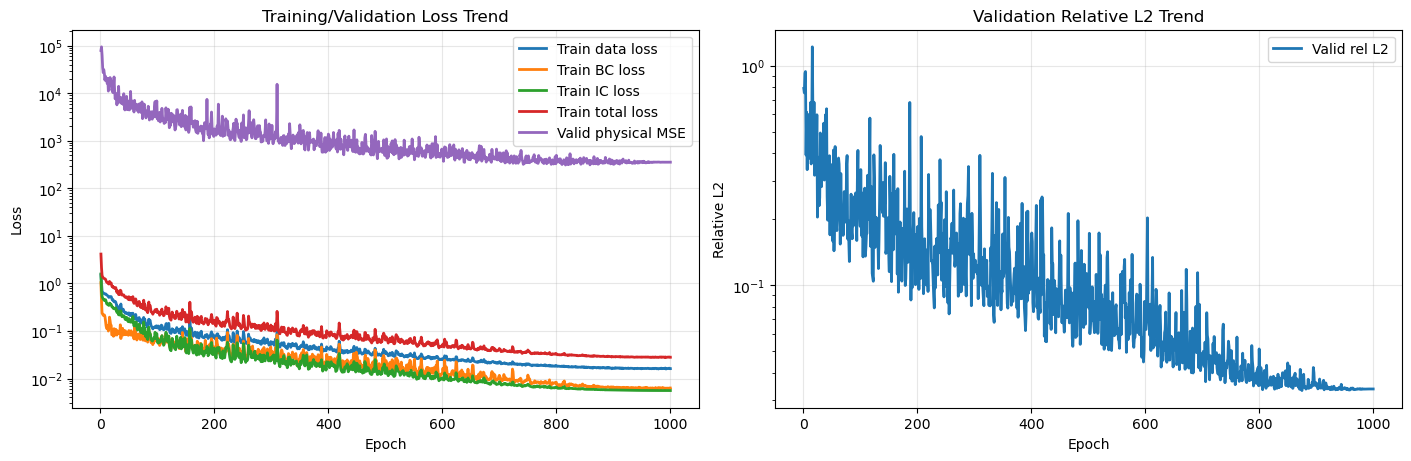

In [ ]:
epochs = np.asarray([h["epoch"] for h in history])
data_loss_arr = np.asarray([h["data_loss"] for h in history])
bc_loss_arr = np.asarray([h["bc_loss"] for h in history])
ic_loss_arr = np.asarray([h["ic_loss"] for h in history])
train_loss_arr = data_loss_arr + bc_loss_arr + ic_loss_arr
valid_loss_arr = np.asarray([h["valid_mse"] for h in history])
valid_rel_l2_arr = np.asarray([h["valid_relative_l2"] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, data_loss_arr, label="Train data loss", linewidth=2)
axes[0].plot(epochs, bc_loss_arr, label="Train BC loss", linewidth=2)
axes[0].plot(epochs, ic_loss_arr, label="Train IC loss", linewidth=2)
axes[0].plot(epochs, train_loss_arr, label="Train total loss", linewidth=2)
axes[0].plot(epochs, valid_loss_arr, label="Valid physical MSE", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation Loss Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, label="Valid rel L2", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()

plt.savefig(output_dir / "loss_history.png", dpi=200)
plt.show()

## Load best checkpoint

In [ ]:
# output_dir = Path("results/transient_072726_1")
checkpoint_path = output_dir / "checkpoint.pt"
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

model = DeepONet(**ckpt["model_config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])

print("Loaded:", checkpoint_path)

/tmp/ipykernel_11064/2999793528.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


Loaded: results/transient_072726_1/checkpoint.pt


## Predict a validation trajectory snapshot

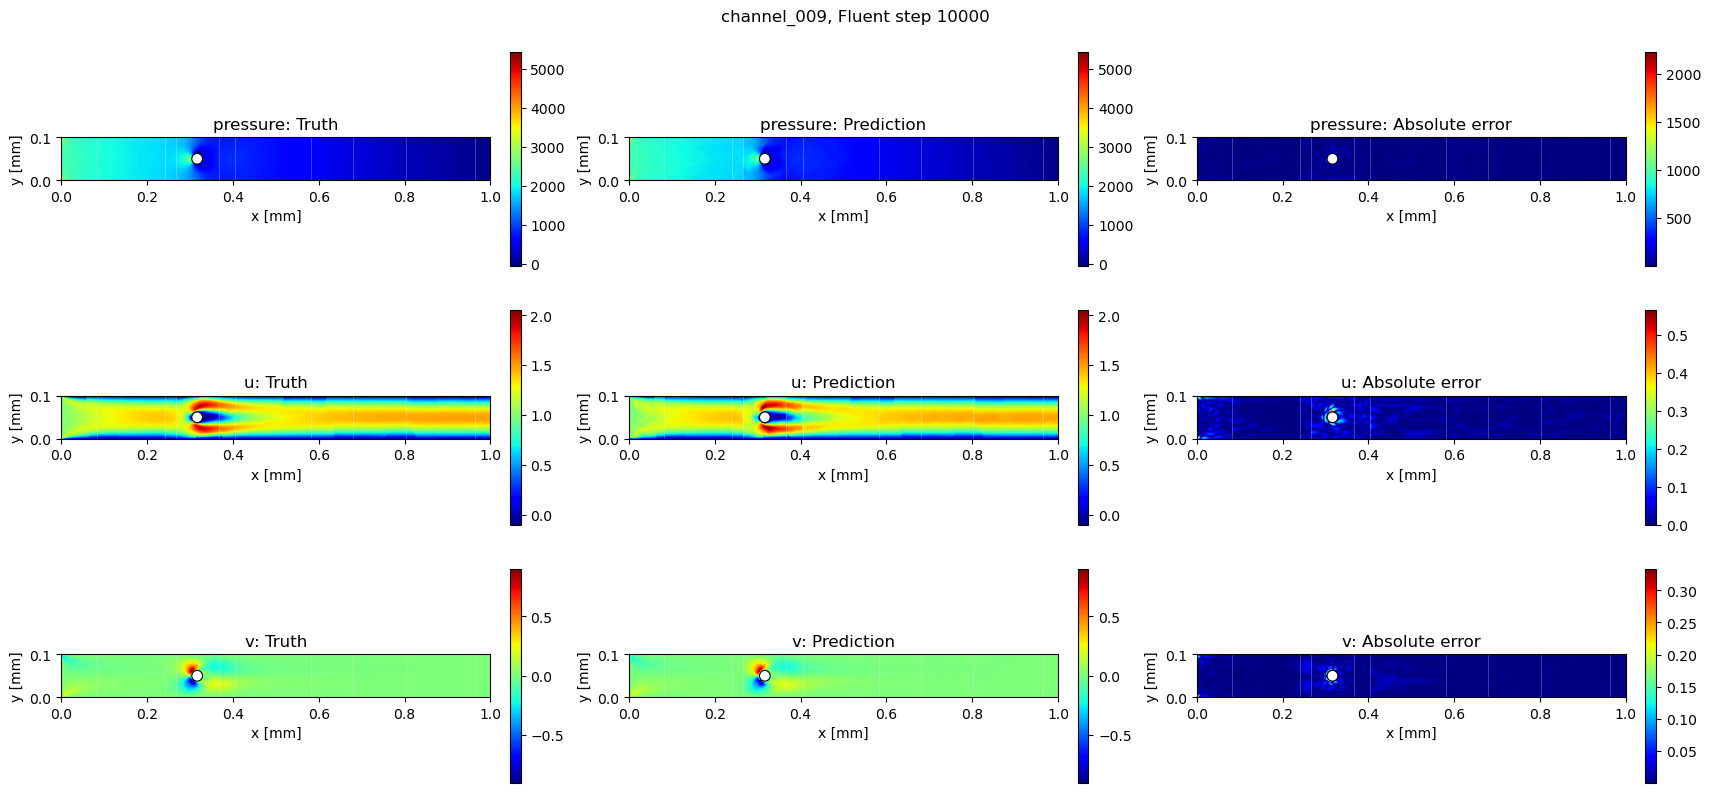

Validation snapshot relative L2: {'pressure': np.float32(0.020276468), 'u': np.float32(0.026481185), 'v': np.float32(0.13623337)}


In [ ]:
def normalize_branch_for_prediction(sample):
    return normalize_transient_branch(
        sample["branch"],
        branch_channel_names,
        output_channel_names,
        y_normalizer.mean.detach().cpu().numpy(),
        y_normalizer.std.detach().cpu().numpy(),
        local_aspect_mean,
        local_aspect_std,
    )

def collect_transient_snapshot_predictions(data, case_id, time_index):
    sample_ids = sorted(
        [i for i, m in enumerate(data["metadata"]) if m["case_id"] == case_id],
        key=lambda i: data["metadata"][i]["subdomain_id"],
    )
    if not sample_ids:
        raise ValueError(f"No samples found for {case_id}")

    geometry = load_rect_cylinder_geometry(
        case_files[case_id]["design"], coordinate_unit="m"
    )
    x_parts, y_parts, pred_parts, truth_parts = [], [], [], []

    for sample_id in sample_ids:
        sample = data["samples"][sample_id]
        metadata = data["metadata"][sample_id]
        spatial = np.asarray(sample["spatial_query"], dtype=np.float32)
        time_value = float(sample["time_query"][time_index])
        query = np.column_stack([
            spatial,
            np.full(spatial.shape[0], time_value, dtype=np.float32),
        ]).astype(np.float32)

        pred = predict_deeponet_points(
            model=model,
            branch=normalize_branch_for_prediction(sample),
            query=query,
            device=DEVICE,
            y_normalizer=y_normalizer,
            query_batch_size=65536,
        ).cpu().numpy()

        x_left = float(metadata["x_left"])
        x_right = float(metadata["x_right"])
        x_parts.append(x_left + spatial[:, 0] * (x_right - x_left))
        y_parts.append(
            float(geometry["ymin"])
            + spatial[:, 1] * (float(geometry["ymax"]) - float(geometry["ymin"]))
        )
        pred_parts.append(pred)
        truth_parts.append(np.asarray(sample["target"][time_index], dtype=np.float32))

    return {
        "x": np.concatenate(x_parts),
        "y": np.concatenate(y_parts),
        "pred": np.concatenate(pred_parts),
        "truth": np.concatenate(truth_parts),
        "geometry": geometry,
        "metadata": [data["metadata"][i] for i in sample_ids],
        "time_index": int(time_index),
        "step": int(data["metadata"][sample_ids[0]]["time_steps"][time_index]),
    }

def plot_transient_snapshot(plot_data, case_id, output_path):
    x_mm = 1.0e3 * plot_data["x"]
    y_mm = 1.0e3 * plot_data["y"]
    pred = plot_data["pred"]
    truth = plot_data["truth"]
    error = np.abs(pred - truth)
    geometry = plot_data["geometry"]

    fig, axes = plt.subplots(
        len(output_channel_names), 3, figsize=(17, 8), constrained_layout=True, squeeze=False
    )
    column_titles = ["Truth", "Prediction", "Absolute error"]
    for field_idx, field_name in enumerate(output_channel_names):
        vmin = min(float(truth[:, field_idx].min()), float(pred[:, field_idx].min()))
        vmax = max(float(truth[:, field_idx].max()), float(pred[:, field_idx].max()))
        for column, values in enumerate((truth[:, field_idx], pred[:, field_idx], error[:, field_idx])):
            kwargs = {"vmin": vmin, "vmax": vmax} if column < 2 else {}
            artist = axes[field_idx, column].scatter(
                x_mm, y_mm, c=values, s=0.35, cmap="jet", linewidths=0, rasterized=True, **kwargs
            )
            for metadata in plot_data["metadata"][:-1]:
                axes[field_idx, column].axvline(1.0e3 * metadata["x_right"], color="white", alpha=0.35, linewidth=0.5)
            cylinder = Circle(
                (1.0e3 * geometry["cylinder_center_x"], 1.0e3 * geometry["cylinder_center_y"]),
                1.0e3 * geometry["cylinder_radius"],
                facecolor="white",
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )
            axes[field_idx, column].add_patch(cylinder)
            axes[field_idx, column].set_xlim(1.0e3 * geometry["xmin"], 1.0e3 * geometry["xmax"])
            axes[field_idx, column].set_ylim(1.0e3 * geometry["ymin"], 1.0e3 * geometry["ymax"])
            axes[field_idx, column].set_aspect("equal", adjustable="box")
            axes[field_idx, column].set_title(f"{field_name}: {column_titles[column]}")
            axes[field_idx, column].set_xlabel("x [mm]")
            axes[field_idx, column].set_ylabel("y [mm]")
            fig.colorbar(artist, ax=axes[field_idx, column], fraction=0.025, pad=0.02)

    fig.suptitle(f"{case_id}, Fluent step {plot_data['step']}")
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200)
    plt.show()

VALID_PLOT_CASE = VALID_CASES[0]
VALID_TIME_INDEX = SNAPSHOTS_PER_SAMPLE - 1
valid_plot_data = collect_transient_snapshot_predictions(
    valid_data, VALID_PLOT_CASE, VALID_TIME_INDEX
)
plot_transient_snapshot(
    valid_plot_data,
    VALID_PLOT_CASE,
    output_dir / "predictions" / "validation" / f"{VALID_PLOT_CASE}_step{valid_plot_data['step']:05d}.png",
)

valid_rel_l2 = np.linalg.norm(valid_plot_data["pred"] - valid_plot_data["truth"], axis=0) / np.maximum(
    np.linalg.norm(valid_plot_data["truth"], axis=0), 1.0e-12
)
print("Validation snapshot relative L2:", dict(zip(output_channel_names, valid_rel_l2)))

# Evaluate test trajectories

Test physical MSE: 703.8598365783691
Test relative L2: 0.03703372646123171
Test channel relative L2: {'pressure': np.float32(0.036827154), 'u': np.float32(0.045036893), 'v': np.float32(0.25377443)}


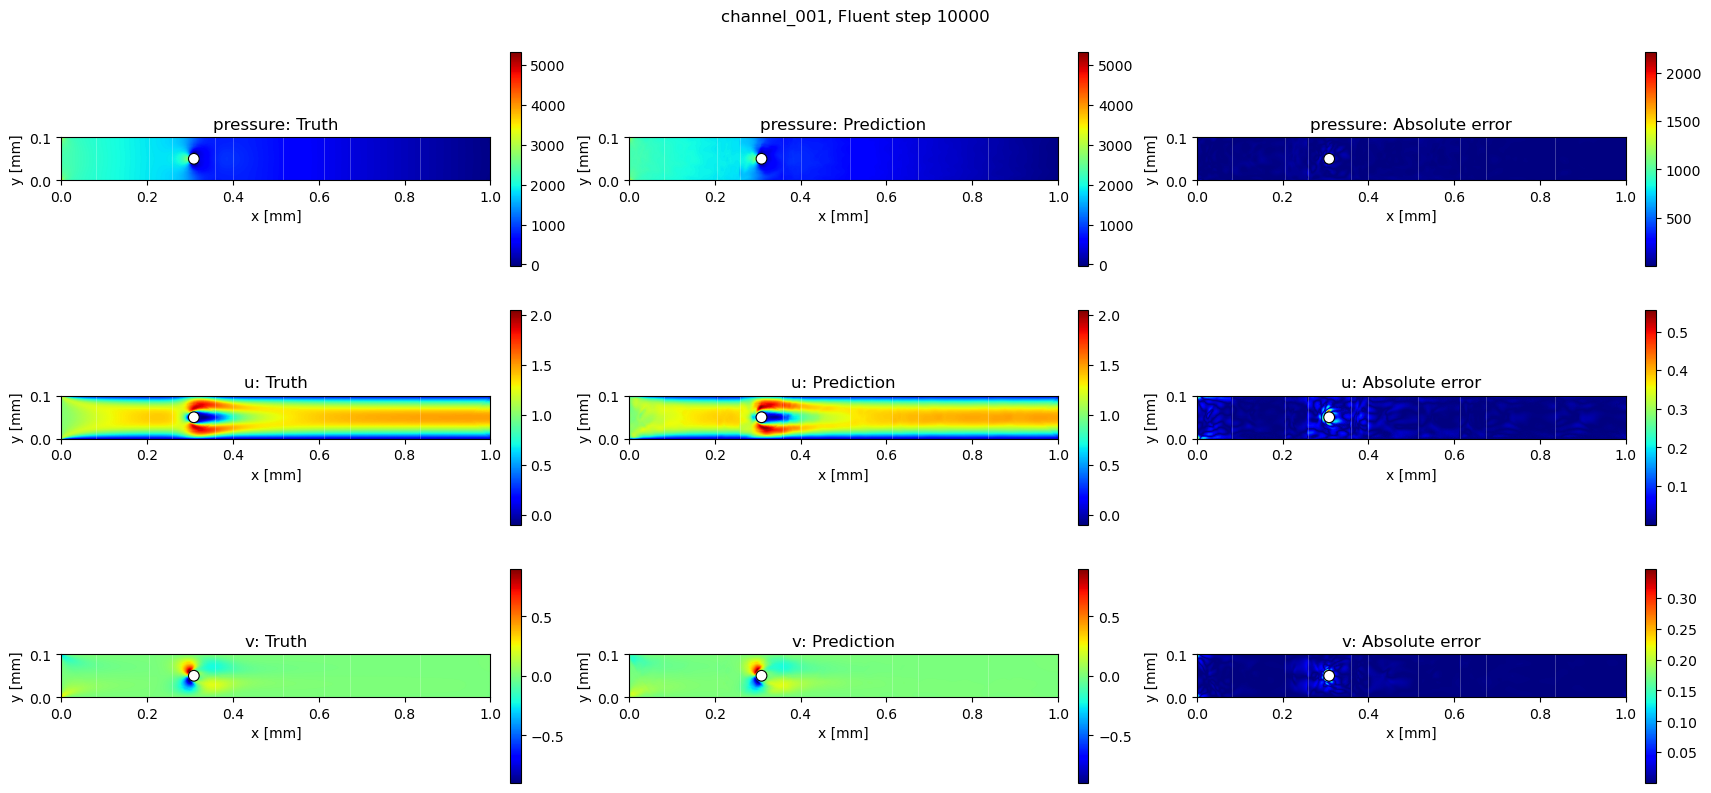

Test snapshot relative L2: {'pressure': np.float32(0.02203782), 'u': np.float32(0.026341695), 'v': np.float32(0.13536045)}


In [ ]:
test_data = build_split_dataset(TEST_CASES, split_seed=300)
test_ds = NormalizedTransientDeepONetCellDataset(
    samples=test_data["samples"],
    n_query_points=N_QUERY_VALID,
    random_query=False,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=branch_channel_names,
    output_channel_names=output_channel_names,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
    pin_memory=DEVICE.type == "cuda",
)

test_metrics = evaluate_deeponet(
    model=model,
    loader=test_loader,
    device=DEVICE,
    y_normalizer=y_normalizer,
)
print("Test physical MSE:", test_metrics["mse"])
print("Test relative L2:", test_metrics["relative_l2"])
print(
    "Test channel relative L2:",
    dict(zip(output_channel_names, test_metrics["channel_relative_l2"])),
)

TEST_PLOT_CASE = TEST_CASES[0]
test_plot_data = collect_transient_snapshot_predictions(
    test_data, TEST_PLOT_CASE, SNAPSHOTS_PER_SAMPLE - 1
)
plot_transient_snapshot(
    test_plot_data,
    TEST_PLOT_CASE,
    output_dir / "predictions" / "test" / f"{TEST_PLOT_CASE}_step{test_plot_data['step']:05d}.png",
)

test_rel_l2 = np.linalg.norm(test_plot_data["pred"] - test_plot_data["truth"], axis=0) / np.maximum(
    np.linalg.norm(test_plot_data["truth"], axis=0), 1.0e-12
)
print("Test snapshot relative L2:", dict(zip(output_channel_names, test_rel_l2)))